Org data dimension is 9.Embedded data dimension is 2
class标签：[0 1]


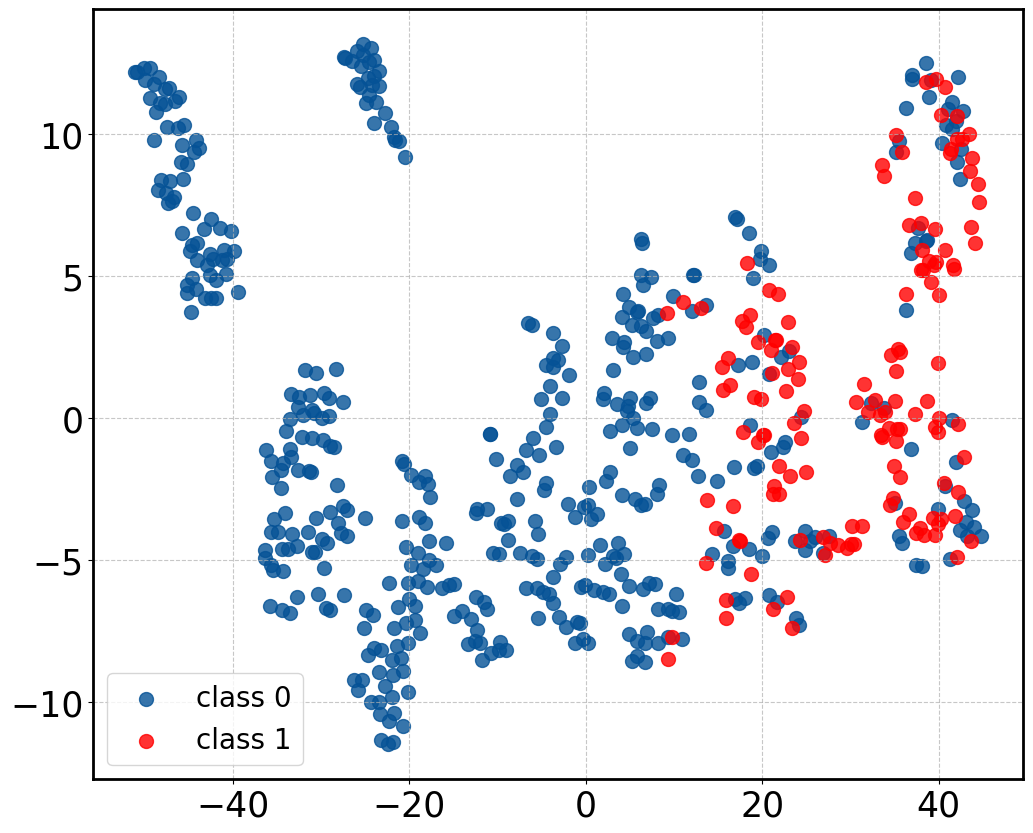

In [1]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold
import numpy as np
from modules import *
import seaborn as sns
#电阻部分
File = './DT_dataset.xlsx'
df = pd.read_excel(File)
X=df.iloc[:, 2:-1] 
y=df.iloc[:, -1] #电阻部分
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=50)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''
x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化

plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(2)
# ax.spines['bottom'].set_linewidth(2)
# ax.spines['left'].set_linewidth(2)
# ax.spines['top'].set_linewidth(2)
# ax.spines['right'].set_linewidth(2)
# 获取class标签
classes = y.unique()
print(f"class标签：{classes}")
colors = ["#055296", 'red']
for i, cls in enumerate(classes):
    indices = y == cls
    plt.scatter(X_tsne[indices, 0], X_tsne[indices, 1], 
                color=colors[i], label=f'class {cls}', s=100, alpha=0.8) 


# plt.xlabel('t-SNE_v1', fontsize=25)
# plt.ylabel('t-SNE_v2', fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)


# path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
# cb.set_label('ρ$_0$×λ×10$^{-16}$/Ωm$^2$', fontsize=15)

#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
#cb.ax.tick_params(size=5,width=1,labelsize=12)
plt.savefig('DT-tSNE.png',dpi=300,bbox_inches='tight')
plt.show()

C:\Users\Estelle\AppData\Local\Temp\ipykernel_3220\3661515703.py:40: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_co_0, shade=True, label='class_0', color='blue')
C:\Users\Estelle\AppData\Local\Temp\ipykernel_3220\3661515703.py:41: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_co_1, shade=True, label='class_1', color='red')


<Figure size 1000x700 with 0 Axes>

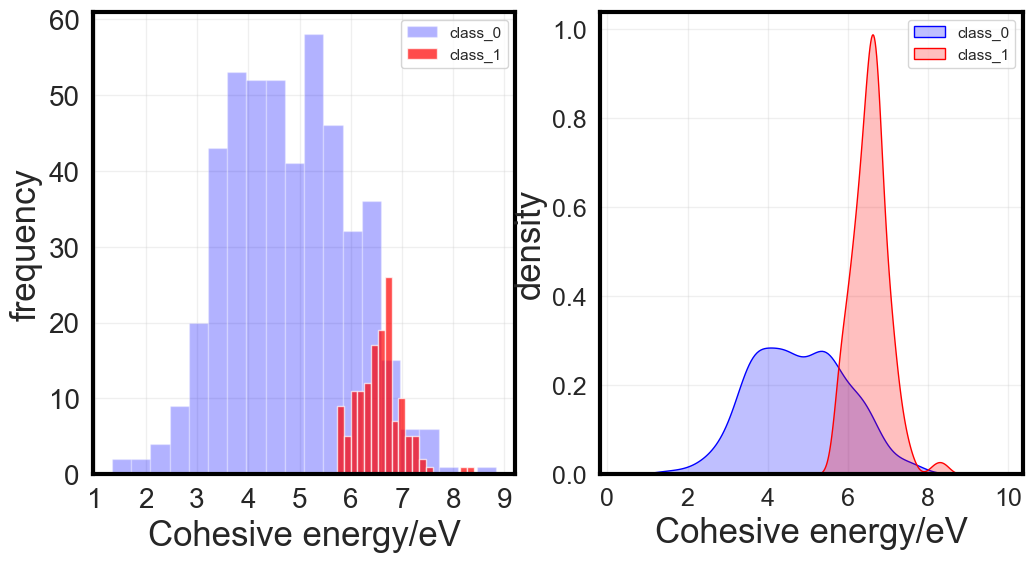

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from modules import *
# import modules
# 设置图形的风格
sns.set(style="whitegrid")
plt.figure(figsize=(10, 7))

data_co_0 = df[df['class_2']== 0]['Co']
data_co_1 = df[df['class_2']== 1]['Co']
data_re_0 = df[df['class_2']== 0]['Re']
data_re_1 = df[df['class_2']== 1]['Re']

plt.figure(figsize=(12, 6))

# 子图1：直方图
plt.subplot(1, 2, 1)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(3)

plt.hist(data_co_0, bins=20, alpha=0.3, label='class_0', color='blue')
plt.hist(data_co_1, bins=20, alpha=0.7, label='class_1', color='red')
# plt.title(f'{column_to_plot}的直方图分布')
plt.xlabel('Cohesive energy/eV',fontsize=25)
plt.ylabel('frequency',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(3)
sns.kdeplot(data_co_0, shade=True, label='class_0', color='blue')
sns.kdeplot(data_co_1, shade=True, label='class_1', color='red')
# plt.title(f'{column_to_plot}的分布曲线')
plt.xlabel('Cohesive energy/eV',fontsize=25)
plt.ylabel('density',fontsize=25)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend()
plt.grid(True, alpha=0.3)

# # 绘制目标值的直方图
# hist_plot = sns.histplot(data_co_0, kde=True, color='red')
# hist_plot.lines[0].set_color('skyblue')  # KDE曲线颜色
# hist_plot.lines[0].set_linewidth(2)  # KDE曲线宽度
# # 获取当前坐标轴并设置边框



# plt.xlabel('Cohesive energy /eV', fontsize=20)
# plt.ylabel('Frequency', fontsize=20)
# # plt.title('Distribution of CoE')
plt.savefig('CoE_distribution.png', dpi=300)
plt.show()

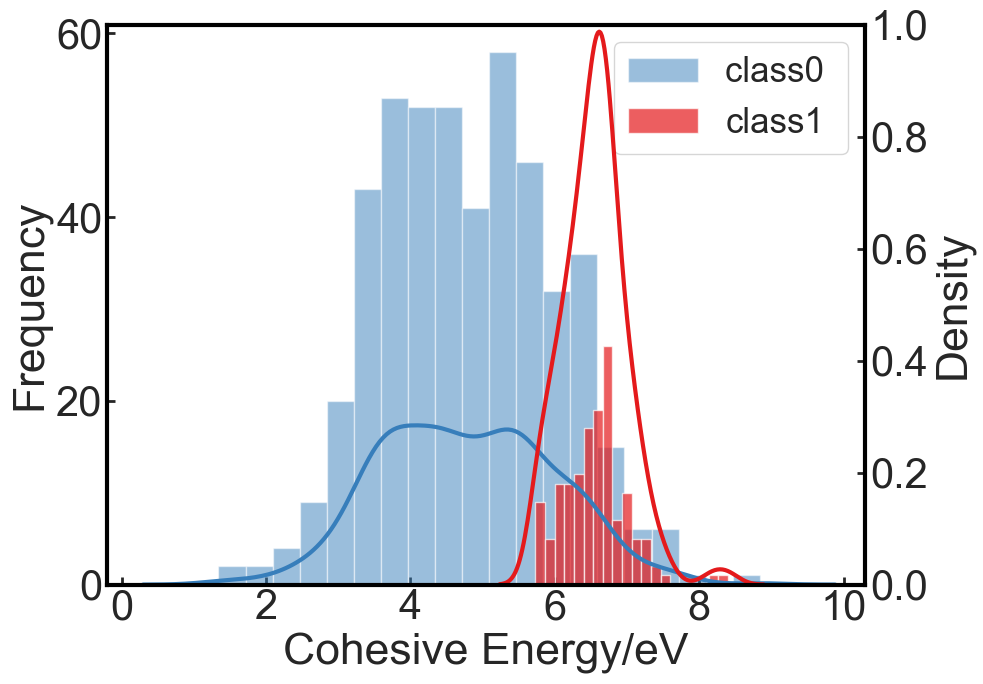

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from modules import *
# import modules
# 设置图形的风格
# sns.set(style="whitegrid")
# plt.figure(figsize=(10, 7))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.right'] = True

data_co_0 = df[df['class_2']== 0]['Co']
data_co_1 = df[df['class_2']== 1]['Co']
data_re_0 = df[df['class_2']== 0]['Re']
data_re_1 = df[df['class_2']== 1]['Re']

plt.figure(figsize=(10, 7))
ax1 = plt.gca()  # 获取当前轴
ax2 = ax1.twinx()  # 创建共用X轴的右Y轴
for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(3)

n0, bins0, patches0 = ax1.hist(data_co_0, bins=20, alpha=0.5, label='class0 ', color='#377EBB')
n1, bins1, patches1 = ax1.hist(data_co_1, bins=20, alpha=0.7, label='class1', color='#E41A1C')

# 7. 在右轴绘制核密度图（密度）
kde0 = sns.kdeplot(data_co_0, ax=ax2, color='#377EBB', linewidth=3)
kde1 = sns.kdeplot(data_co_1, ax=ax2, color='#E41A1C', linewidth=3)

# 8. 设置轴标签和标题
ax1.set_xlabel('Cohesive Energy/eV',  fontsize=32)
ax1.set_ylabel('Frequency', fontsize=32)
ax2.set_ylabel('Density', fontsize=32)


# 9. 设置轴的颜色，与对应的数据颜色一致
ax1.tick_params(axis='y', labelsize=30,width=2)
ax1.tick_params(axis='x', labelsize=30,width=2)
ax2.tick_params(axis='y',labelsize=30,width=2)
ax1.set_xlim(-0.2, 10.3)
ax2.set_ylim(0.0,1.0)

# #10. 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=25)
ax1.grid(False)
ax2.grid(False)

# 11. 添加网格线
# ax1.grid(True, alpha=0.3)


# 12. 调整布局
plt.tight_layout()
plt.savefig('CoE_distribution-1.png', dpi=300)
plt.show()

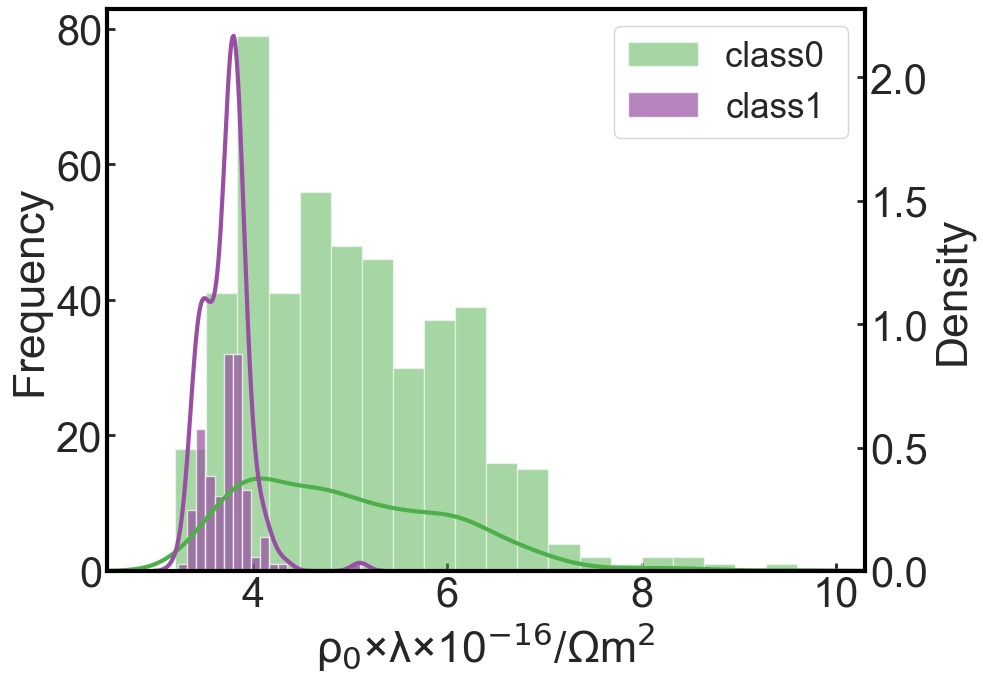

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from modules import *
# import modules
# 设置图形的风格
# sns.set(style="whitegrid")
# plt.figure(figsize=(10, 7))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.right'] = True

data_co_0 = df[df['class_2']== 0]['Co']
data_co_1 = df[df['class_2']== 1]['Co']
data_re_0 = df[df['class_2']== 0]['Re']
data_re_1 = df[df['class_2']== 1]['Re']

plt.figure(figsize=(10, 7))
ax1 = plt.gca()  # 获取当前轴
ax2 = ax1.twinx()  # 创建共用X轴的右Y轴
for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(3)

n0, bins0, patches0 = ax1.hist(data_re_0, bins=20, alpha=0.5, label='class0 ', color='#4daf4a')
n1, bins1, patches1 = ax1.hist(data_re_1, bins=20, alpha=0.7, label='class1', color='#984EA3')

# 7. 在右轴绘制核密度图（密度）
kde0 = sns.kdeplot(data_re_0, ax=ax2, color='#4daf4a', linewidth=3)
kde1 = sns.kdeplot(data_re_1, ax=ax2, color='#984EA3', linewidth=3)

# 8. 设置轴标签和标题
ax1.set_xlabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',  fontsize=32)
ax1.set_ylabel('Frequency', fontsize=32)
ax2.set_ylabel('Density', fontsize=32)


# 9. 设置轴的颜色，与对应的数据颜色一致
ax1.tick_params(axis='y', labelsize=30, width=2)
ax1.tick_params(axis='x', labelsize=30, width=2)
ax2.tick_params(axis='y',labelsize=30,width=2)
ax1.set_xlim(2.5, 10.3)
# ax2.set_ylim(0.0,1.0)
# #10. 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=25)
ax1.grid(False)
ax2.grid(False)

# 11. 添加网格线
# ax1.grid(True, alpha=0.3)


# 12. 调整布局
plt.tight_layout()
plt.savefig('CoE_distribution-2.png', dpi=300)
plt.show()

# 整体的点的分布，分预测和实际

Org data dimension is 6.Embedded data dimension is 2


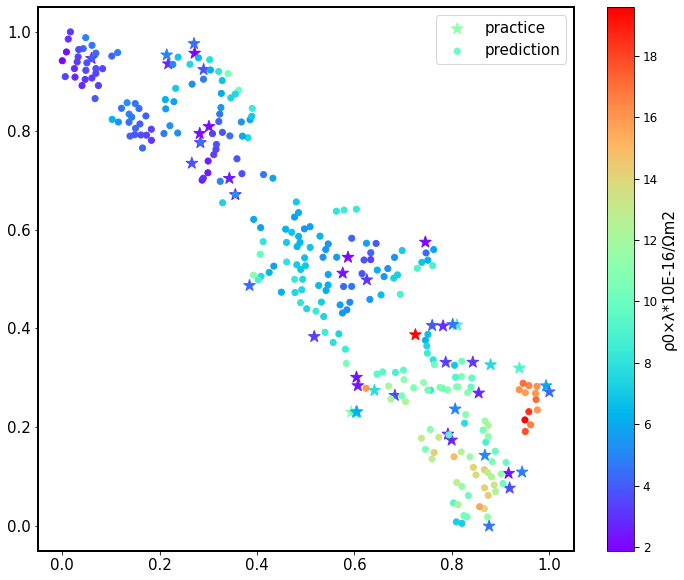

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

File = '../newdata/NT-EL'

X,y=sub_data(File)
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
#X=np.delete(X,[0,1,4,5],axis=1)
# 电阻部分去除异常数据
# X=np.delete(X,[29],axis=0)
# y=np.delete(y,[29],axis=0)
# # #用于除去实验数据
# X=np.delete(X,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)


'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
# X_norm=np.delete(X_norm,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)
#y=np.delete(y,[0,1,2],axis=1)
#print(X_norm[-6:,:])
#plt.figure()

plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
is_first_43_rows = np.arange(X_norm.shape[0]) < 45
# 内聚能部分
#is_first_43_rows = np.arange(X_norm.shape[0]) < 40

# 为前43行和剩余行分别绘制散点图
plt.scatter(X_norm[is_first_43_rows, 0], X_norm[is_first_43_rows, 1], 
            c=y[is_first_43_rows], cmap=plt.cm.rainbow, 
            marker='*',s=150, alpha=1, label='practice')  # 使用三角形标记

plt.scatter(X_norm[~is_first_43_rows, 0], X_norm[~is_first_43_rows, 1], 
            c=y[~is_first_43_rows], cmap=plt.cm.rainbow, s=150,alpha=1, 
            marker ='.',label='prediction')  # 使用圆形标记

#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# 添加图例
plt.legend(fontsize=15)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
#cb.set_label('cohesive/ev', fontsize=15)
cb.set_label('ρ$_0$×λ×10$^{-16}$/Ωm$^2$', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
cb.ax.tick_params(size=5,width=1,labelsize=12)

plt.savefig('NO-EL.png',dpi=300,bbox_inches='tight')
plt.show()

# 联合密度分布

In [51]:
def plot_train_test_results_1(y_train,y_test,y_pre1,y_pre2,output=True,fname='EC',plt_prop=True,patt='Set1'):
   train_typ,test_typ=[],[]
   for i in range(38):
     train_typ+=['Train']
   for i in range(266):
     test_typ+=['Test']
   data0=np.transpose(np.vstack((y_train,y_pre1)))
   d0=pd.DataFrame(data0,columns=['Calculated Values(ev)','Predicted Values(eev)'])

   data1=np.transpose(np.vstack((train_typ,y_train,y_pre1)))
   d1=pd.DataFrame(data1,columns=['Type','Calculated Values(ev)','Predicted Values(ev)'])

   data2=np.transpose(np.vstack((test_typ,y_test,y_pre2)))
   d2=pd.DataFrame(data2,columns=['Type','Calculated Values(ev)','Predicted Values(ev)'])

   data=np.vstack((data1,data2))
   d3=pd.DataFrame(data,columns=['Type','Calculated Values(ev)','Predicted Values(ev)'])
   d3["Calculated Values(ev)"]=pd.to_numeric(d3["Calculated Values(ev)"])
   d3["Predicted Values(ev)"]=pd.to_numeric(d3["Predicted Values(ev)"])
    
   lim0=min(min(y_train),min(y_pre1),min(y_test),min(y_pre2))
   lim1=max(max(y_train),max(y_pre1),max(y_test),max(y_pre2))
   sns.set_context("talk",font_scale=1.5,rc={'font.size': 25.0,
 'legend.fontsize':20,
 'legend.title_fontsize':20,
 'axes.linewidth':2.0,
 'axes.labelsize': 20.0,
 'axes.titlesize': 20.0,
 'xtick.labelsize': 16.5,
 'ytick.labelsize': 16.5,})

   g=sns.JointGrid(x='Calculated Values(ev)', y='Predicted Values(ev)', hue='Type',data=d3,space=0.0,height=10,ratio=10,xlim=(lim0,lim1), ylim=(lim0,lim1))
   # 设置轴名称为空
   g.set_axis_labels("", "")
   #g=sns.JointGrid(x='Calculated Values(eV)', y='Predicted Values(eV)', hue='Type',data=d3,space=0.0,height=10,ratio=10,xlim=(-7.5,1), ylim=(-7.5,1))
   g.plot_joint(sns.scatterplot,s=75, palette=patt,legend='auto')
   g.plot_marginals(sns.kdeplot,fill=True,palette=patt,common_norm=False)
   
   '''
   g=sns.JointGrid(x='Calculated Values(eV)', y='Predicted Values(eV)', data=d3)
   g=g.plot_joint(plt.scatter,color='g',s=40,edgecolor='white')
   plt.grid(linestyle='--')
   #g.plot_marginals(sns.distplot,kde=True,color='g')
   g.plot_marginals(sns.kdeplot,shade=True,color='g')
   '''
   if output:
      plt.savefig(f'{fname}.png',dpi=300)
   if plt_prop:
      plt.show()


Org data dimension is 7.Embedded data dimension is 2


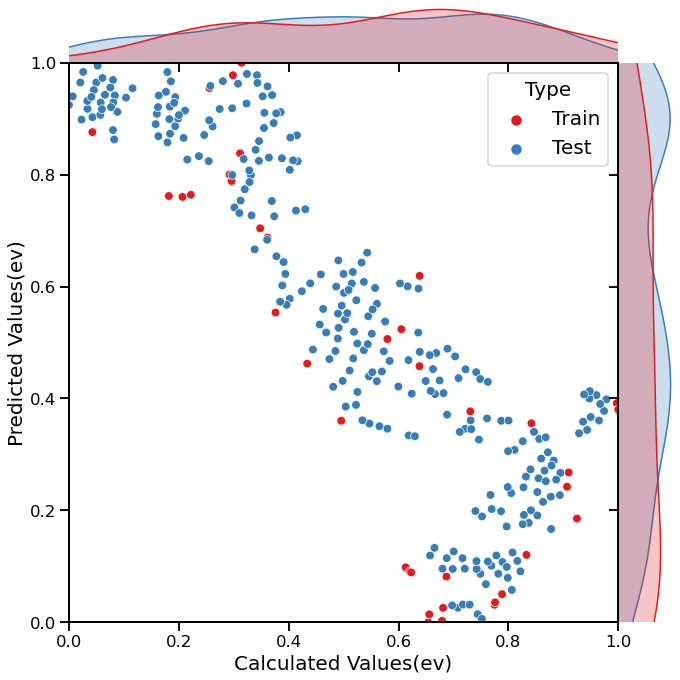

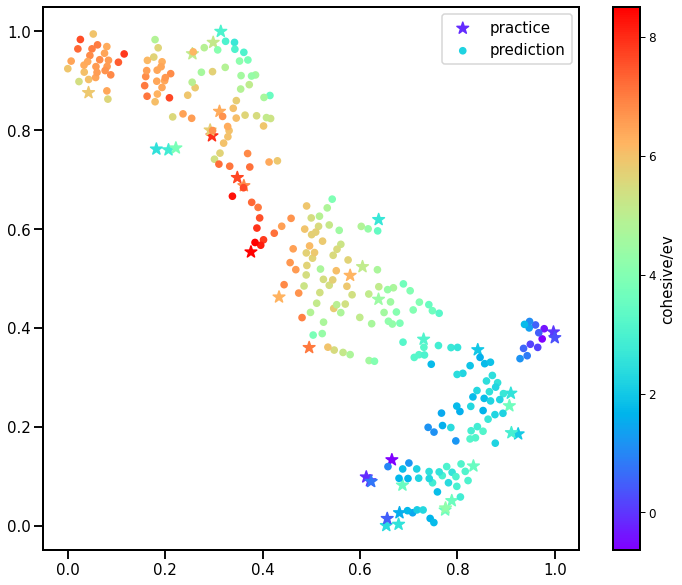

In [53]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

File = '../newdata/NT-CO'

X,y=sub_data(File)
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
#X=np.delete(X,[0,1,4,5],axis=1)
# 电阻部分去除异常数据
# X=np.delete(X,[29],axis=0)
# y=np.delete(y,[29],axis=0)
# # #用于除去实验数据
# X=np.delete(X,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)


'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
y_train =[]
y_pre1=[]
y_test=[]
y_pre2=[]
# y_train =X_norm[:43,0]
# y_pre1=X_norm[:43,1]
# y_test=X_norm[44:,0]
# y_pre2=X_norm[44:,1]
# 内聚能
y_train =X_norm[:38,0]
y_pre1=X_norm[:38,1]
y_test=X_norm[39:,0]
y_pre2=X_norm[39:,1]


plot_train_test_results_1(y_train,y_test,y_pre1,y_pre2)

plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
#is_first_43_rows = np.arange(X_norm.shape[0]) < 45
#内聚能
is_first_43_rows = np.arange(X_norm.shape[0]) < 40

# 为前43行和剩余行分别绘制散点图
plt.scatter(X_norm[is_first_43_rows, 0], X_norm[is_first_43_rows, 1], 
            c=y[is_first_43_rows], cmap=plt.cm.rainbow, 
            marker='*',s=150, alpha=1, label='practice')  # 使用三角形标记

plt.scatter(X_norm[~is_first_43_rows, 0], X_norm[~is_first_43_rows, 1], 
            c=y[~is_first_43_rows], cmap=plt.cm.rainbow, s=150,alpha=1, 
            marker ='.',label='prediction')  # 使用圆形标记

# 绘制边缘联合分布
#g.plot_marginals(sns.kdeplot,fill=True,palette=patt,common_norm=False) 

#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# 添加图例
plt.legend(fontsize=15)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('cohesive/ev', fontsize=15)
#cb.set_label('ρ0×λ*10E-16/Ωm2', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
cb.ax.tick_params(size=5,width=1,labelsize=12)

plt.savefig('NO-EL.png',dpi=300,bbox_inches='tight')
plt.show()

(100, 6)
Org data dimension is 6.Embedded data dimension is 2


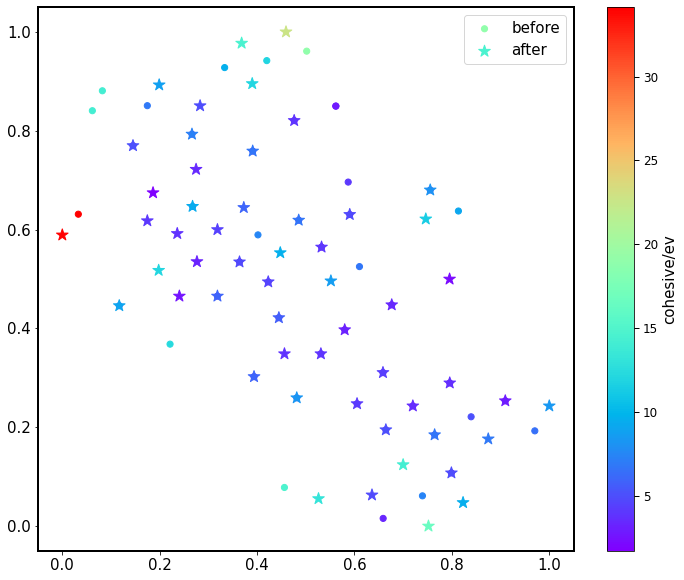

In [1]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

File = '../newdata/fenbuceshi-EL'

X,y=sub_data(File)
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
#X=np.delete(X,[0,1,4,5],axis=1)
# 电阻部分去除异常数据
# X=np.delete(X,[29],axis=0)
# y=np.delete(y,[29],axis=0)
# # #用于除去实验数据
# X=np.delete(X,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)
print(X.shape)

'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化
# X_norm=np.delete(X_norm,list(range(43)),axis=0)
# y=np.delete(y,list(range(43)),axis=0)
#y=np.delete(y,[0,1,2],axis=1)
#print(X_norm[-6:,:])
#plt.figure()
#print(X_norm)
plt.figure(figsize=(12,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
is_first_43_rows = np.arange(X_norm.shape[0]) < 46

# 内聚能部分
#is_first_43_rows = np.arange(X_norm.shape[0]) < 40

# 为前43行和剩余行分别绘制散点图
plt.scatter(X_norm[is_first_43_rows, 0], X_norm[is_first_43_rows, 1], 
            c=y[is_first_43_rows], cmap=plt.cm.rainbow, 
            marker='.',s=150, alpha=1, label='before')  # 使用三角形标记

plt.scatter(X_norm[~is_first_43_rows, 0], X_norm[~is_first_43_rows, 1], 
            c=y[~is_first_43_rows], cmap=plt.cm.rainbow, s=150,alpha=1, 
            marker ='*',label='after')  # 使用圆形标记

#path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
# 添加图例
plt.legend(fontsize=15)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('cohesive/ev', fontsize=15)
#cb.set_label('ρ0×λ*10E-16/Ωm2', fontsize=15)
#cb.ax.tick_params(length=2)
#cb.ax.tick_params(size=1,width=1,color='b')
cb.ax.tick_params(size=5,width=1,labelsize=12)

plt.savefig('NO-EL.png',dpi=300,bbox_inches='tight')
plt.show()